<a href="https://colab.research.google.com/github/Megeeee/AgenticAI/blob/AntrophicAgent/AnthrophicAPIAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install anthropic

import anthropic

client = anthropic.Anthropic()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 45.6 MB/s eta 0:00:00


In [21]:
# Define your tools (these wrap your PyTorch models)
tools = [
     {
        "name": "classify_digit",
        "description": "Classify a handwritten digit (0-9) in a local image using a trained "
                    "MNIST CNN. Returns the predicted digit, confidence, and the full "
                    "probability distribution over all 10 classes.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the image file"}
            },
            "required": ["image_path"]
        },

    },
    {
        "name": "classify_cxr",
        "description": "Run chest X-ray classifier. Returns findings with confidence scores.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string", "description": "Path to the DICOM file"}
            }
        }
    },
    {
        "name": "segment_lesion",
        "description": "Segment lesions in the image. Returns mask and measurements.",
        "input_schema": {
            "type": "object",
            "properties": {
                "image_path": {"type": "string"},
                "finding": {"type": "string", "description": "What to segment, e.g. 'nodule'"}
            }
        }
    },
    {
        "name": "search_guidelines",
        "description": "Search radiology guidelines for management recommendations.",
        "input_schema": {
            "type": "object",
            "properties": {
                "query": {"type": "string"}
            }
        }
    }
]

# The agent loop
messages = [
    {"role": "user", "content": (
        "You are a radiology AI assistant. A new chest X-ray has arrived.\n"
        "Clinical context: 55yo male, cough for 3 weeks, smoker.\n"
        "Study path: /studies/patient_123/cxr_001.dcm\n"
        "Analyze this study and produce a structured report."
    )}
]

In [ ]:
!pip install torchinfo

In [2]:
import cnn_model
import torch
CNN = cnn_model.CNNModel(28,28).to("cuda")

testdataloader = cnn_model.MNISTtestloaderload()
traindataloader = cnn_model.MNISTtrainloaderload()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.74MB/s]


Training on:} NVIDIA A100-SXM4-80GB
[Epoch: 1, Batch: 200] loss: 0.097
[Epoch: 1, Batch: 400] loss: 0.085
[Epoch: 1, Batch: 600] loss: 0.080
[Epoch: 1, Batch: 800] loss: 0.078
[Epoch: 2, Batch: 200] loss: 0.062
[Epoch: 2, Batch: 400] loss: 0.064
[Epoch: 2, Batch: 600] loss: 0.061
[Epoch: 2, Batch: 800] loss: 0.055
[Epoch: 3, Batch: 200] loss: 0.047
[Epoch: 3, Batch: 400] loss: 0.047
[Epoch: 3, Batch: 600] loss: 0.059
[Epoch: 3, Batch: 800] loss: 0.052
[Epoch: 4, Batch: 200] loss: 0.043
[Epoch: 4, Batch: 400] loss: 0.044
[Epoch: 4, Batch: 600] loss: 0.040
[Epoch: 4, Batch: 800] loss: 0.041
[Epoch: 5, Batch: 200] loss: 0.035
[Epoch: 5, Batch: 400] loss: 0.033
[Epoch: 5, Batch: 600] loss: 0.041
[Epoch: 5, Batch: 800] loss: 0.043


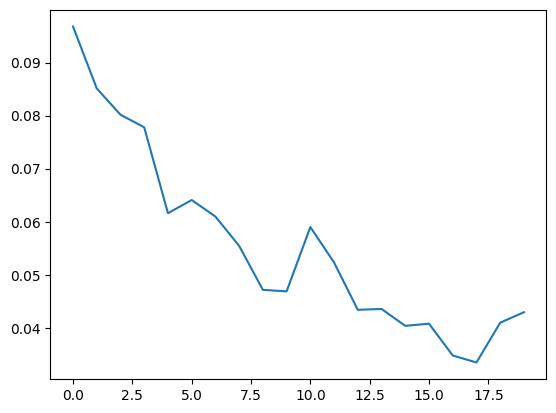

Finished Training


In [7]:
cnn_model.train(CNN,traindataloader,epochsize=5)

In [17]:
from PIL import Image, ImageOps
from torchvision import transforms
import torch.nn.functional as F
import json

In [10]:
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean/std
])

In [12]:
def classify_digit(image_path: str) -> dict:
    img = Image.open(image_path).convert("L")

    x = preprocess(img).unsqueeze(0).to("cuda")
    with torch.inference_mode():
        probs = F.softmax(CNN(x), dim=1)[0]

    return {
        "predicted_digit": int(probs.argmax().item()),
        "confidence": round(probs.max().item(), 4),
        "all_probabilities": {
            str(d): round(p.item(), 4) for d, p in enumerate(probs)
        },
    }


In [16]:
TOOL_REGISTRY = {"classify_digit": classify_digit}

In [22]:
def chat(user_prompt: str) -> str:
   messages = [{"role": "user", "content": user_prompt}]

   while True:
        resp = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=1024,
            tools=tools,
            messages=messages,
        )
        messages.append({"role": "assistant", "content": resp.content})

        if resp.stop_reason != "tool_use":
            return "".join(b.text for b in resp.content if b.type == "text")

        results = []
        for block in resp.content:
            if block.type == "tool_use":
                try:
                    out = TOOL_REGISTRY[block.name](**block.input)
                except Exception as e:
                    out = {"error": str(e)}

                results.append({
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": json.dumps(out),
                })
        messages.append({"role": "user", "content": results})

In [24]:
if __name__ == "__main__":
    print(chat(
        "I have a handwritten digit at /content/1056.png "
        "and /content/1232.png What digit are they, and how confident are you?"
    ))

Here are the results for both images:

| Image | Predicted Digit | Confidence |
|---|---|---|
| `/content/1056.png` | **2** | **100.00%** |
| `/content/1232.png` | **9** | **99.98%** |

### Details:
- **1056.png** — The model is virtually certain this is a **2**, with a perfect confidence score of **100%**. All other digits received 0% probability.
- **1232.png** — The model is extremely confident this is a **9**, scoring **99.98%**. The only other candidate was an **8** with a negligible 0.02% probability, which makes sense given their visual similarity.

Overall, the model is highly confident in both predictions! 🎯
